In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_nof_1wave/'

# datafilename = 'sun_out.nc_0000.nc'
datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

In [4]:
data_Cadv = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_Cadv.nc')

In [5]:
Data = xr.open_dataset('sun_out.nc_0000.nc')

In [ ]:
z_r_ = Data.z_r.copy()
time_ = Data.time.copy()
temp_ = np.reshape(Data.temp[:,:,idx_section_].data, (len(time_.data), len(z_r_.data), N_section_), order='F')
u_ = np.reshape(Data.uc[:,:,idx_section_].data, (len(time_.data), len(z_r_.data), N_section_), order='F')

# Scale time

In [5]:
dt = (data.time.data-data.time[0].data).astype('int')*1e-9
c = 1.715370234806147
L_w = 6.387548003396961e+03/2

T_scale = L_w*2/c
t_nondim = dt/T_scale

# Island center & Shoaling depth

In [6]:
lambdaM2=70.1e3
l_sponge = 20e3
L=1.5*lambdaM2+2*l_sponge
W=1.5*lambdaM2

x_c = 2*l_sponge+1.5*lambdaM2/2 
y_c = W/2

In [7]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

# x,y coordinate

In [8]:
# read data
Data = xr.open_dataset(datafilepath+datafilename)

# grid info
import mat73
grid = mat73.loadmat('/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/mfiles/SUNTANS_grid.mat', only_include=['Nk', 'Nx', 'Ny', 'Depth', 'INPUT']) 

Nx = grid['Nx'].astype('int')
Ny = grid['Ny'].astype('int')
Nk = grid['Nk'].astype('int')
Nc = Nx*Ny
# Depth = np.reshape(grid['Depth'].astype('int'), (Nx, Ny), order='F')
Depth = np.reshape(grid['Depth'], (Nx, Ny), order='F')

xv = np.reshape(Data.xv.data, (Nx, Ny), order='F')
yv = np.reshape(Data.yv.data, (Nx, Ny), order='F')

# Barotropic velocity

In [9]:
U = np.reshape(Data.Ubt.data, (len(Data.time), Nx, Ny), order='F')
V = np.reshape(Data.Vbt.data, (len(Data.time), Nx, Ny), order='F')

# evolution of wave

In [ ]:
count = 0
for idx_t_data in np.arange(42,100+1,3):
    
    idx_t_ = count+14
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,1.2))
    ax.fill_between(xv[:,0], -Depth[:,int(Ny/2)], np.zeros(xv[:,0].shape)-600, color='.5')
    im = ax.pcolormesh(xv_.data, -z_r_.data, u_[idx_t_,:,:].data, vmin=-.5, vmax=.5, cmap='RdBu_r')
    ax.contour(xv_.data, -z_r_.data, temp_[idx_t_,:,:].data, param_plot['slice_contour'], colors='k', linewidths=1)
    ax.contour(xv_.data, -z_r_.data, temp_[idx_t_,:,:].data, param_plot['slice_contour_light'], colors='.3', linewidths=.5)
    ax.text(x_c+8500, -180, f"t = {np.round(t_nondim[idx_t_data],2)}", fontsize=14, color='w')
    ax.set_xticks(np.arange(x_c+8000,x_c+20000+1,2000))
    ax.set_yticks(np.arange(-200,1e-4,100))
    if idx_t_data == 99:
        ax.set_yticklabels(['-200', '-100', '0'])
        ax.set_xticklabels(['8', '10', '12', '14', '16', '18', '20'])
        ax.set_xlabel('x [km]', fontsize=14)
        ax.set_ylabel('z [m]', fontsize=14)
    else:
        ax.set_yticklabels('')
        ax.set_xticklabels('')
        ax.set_xlabel('')
        ax.set_ylabel('')
    ax.set_xlim([x_c+8000,x_c+20000])
    ax.set_ylim([-200,0])
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    # fig.tight_layout()
    plt.savefig(f"T_slice_summer_nof_t{idx_t_data}.png", dpi=300, transparent=True)
    count+=1

# evolution of energy budget

In [12]:
dissip0 = data.dissip0[:,:,int(Ny/2)]
dissip_prime = data.dissip_prime[:,:,int(Ny/2)]

# spatially filter dissipation; running mean, binsize = N
N = 10
dissip_0_filter = dissip0.data.copy()
dissip_prime_filter = dissip_prime.data.copy()

for idx_t in range(len(data.time)):
    dissip_prime_filter[idx_t,:] = np.convolve(dissip_prime_filter[idx_t,:], np.ones(N)/N, 'same')
    dissip_0_filter[idx_t,:] = np.convolve(dissip_0_filter[idx_t,:], np.ones(N)/N, 'same')

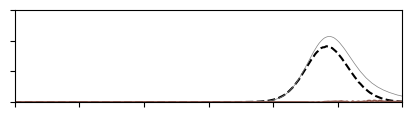

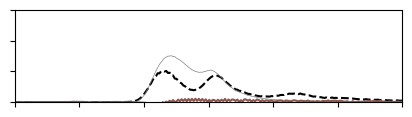

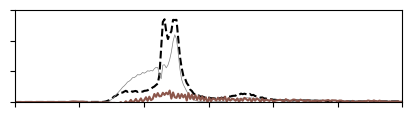

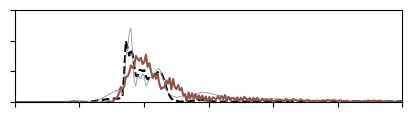

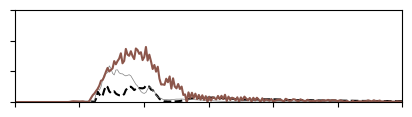

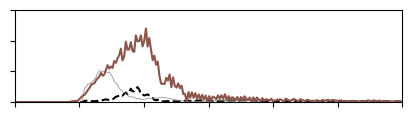

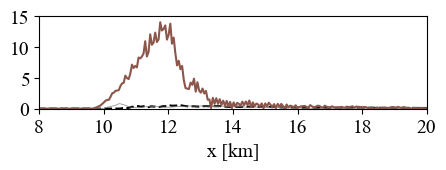

In [15]:
count = 0
for idx_t_data in [48, 60, 66, 72, 78, 84, 99]:
    
    fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(5,1.2))

    ax1.plot(data.x.data, (data_.dEk_prime[idx_t_data,:,int(Ny/2)].data+data_.dEk0[idx_t_data,:,int(Ny/2)].data)/1e3, 'k--')
    ax1.plot(data.x.data, (data_.dEp_prime[idx_t_data,:,int(Ny/2)].data+data_.dEp0[idx_t_data,:,int(Ny/2)].data)/1e3, c='gray', lw=.5)
    # ax1.plot(data.x.data, (data.dissip_prime[idx_t_data,:,int(Ny/2)].data+data.dissip0[idx_t_data,:,int(Ny/2)].data+data_.D0[idx_t_data,:,int(Ny/2)].data+data_.D_prime[idx_t_data,:,int(Ny/2)].data)/1e3, c='tab:brown')
    ax1.plot(data.x.data, (dissip_prime_filter[idx_t_data,:]+dissip_0_filter[idx_t_data,:]+data_.D0[idx_t_data,:,int(Ny/2)].data+data_.D_prime[idx_t_data,:,int(Ny/2)].data)/1e3, c='tab:brown')
 
    ax1.set_xticks(np.arange(x_c+8000,x_c+20000+1,2000))
    ax1.set_xlim([x_c+8000,x_c+20000])
    ax1.set_ylim([0,15])
    ax1.set_yticks(np.arange(0,15+1e-4,5))
    if idx_t_data == 99:
        ax1.set_yticklabels(['0', '5', '10', '15'])
        ax1.set_xticklabels(['8', '10', '12', '14', '16', '18', '20'])
        ax1.set_xlabel('x [km]', fontsize=14)
    else:
        ax1.set_yticklabels('')
        ax1.set_xticklabels('')
        
    ax1.tick_params(axis='both', which='major', labelsize=14)
    ax1.set_ylabel('')

    plt.rcParams["font.family"] = "Times New Roman"
    # fig.tight_layout()
    plt.savefig(outfilepath+ f"Ek_Ep_slice_summer_nof_t{idx_t_data}.png", transparent=True, dpi=300)

    count+=1


# evolution of bt velocities

In [17]:
data["HU"]=(['time', 'x', 'y'],  Depth*U)
data["HV"]=(['time', 'x', 'y'],  Depth*V)

W = -data["HU"].differentiate("x")+data["HV"].differentiate("y")

In [21]:
# spatially filter dissipation; running mean, binsize = N
N = 10
W_filter = W[:,:,int(Ny/2)].copy()

for idx_t in range(len(data.time)):
    W_filter[idx_t,:] = np.convolve(W_filter[idx_t,:], np.ones(N)/N, 'same')

In [12]:
C = data_.C_int.differentiate("time",datetime_unit="s")

In [13]:
# # calculate W
# data_f=xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bt_flux_x.nc')

# Fx_03_ = data_f.Fx_03_int.differentiate("time",datetime_unit="s")
# del data_f
# rho0 = 1000
# grav = 9.81
# p_prime_ = Fx_03_/U

# C1_int = np.reshape(Data.C1_int.data, (len(Data.time), Nx, Ny), order='F')
# data["C1_int"]=(['time', 'x', 'y'],  C1_int)

# C1 = data.C1_int.differentiate("time",datetime_unit="s")

# W = C1/p_prime_/grav

# C = data_.C_int.differentiate("time",datetime_unit="s")

In [38]:
np.arange(-.8,.8+1e-4,10)

array([-0.8])

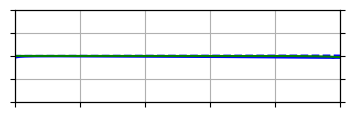

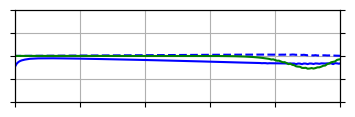

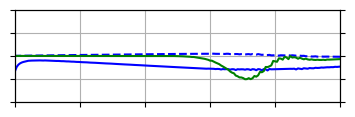

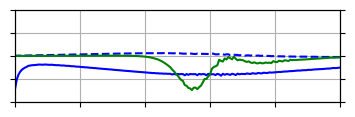

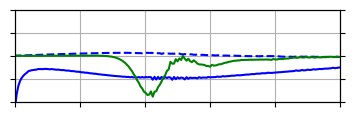

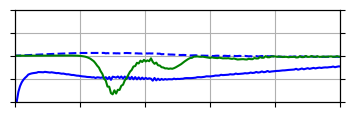

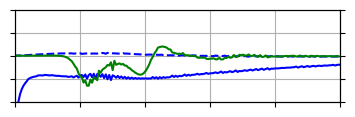

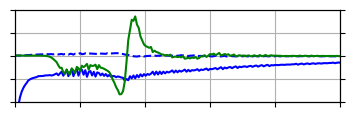

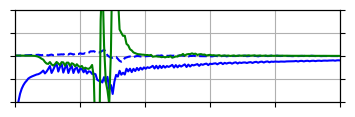

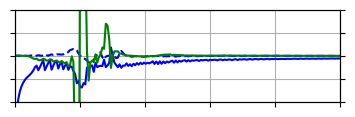

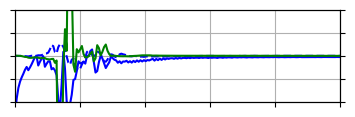

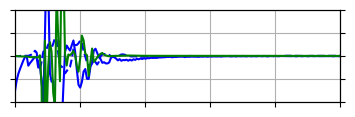

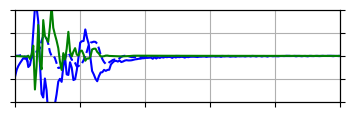

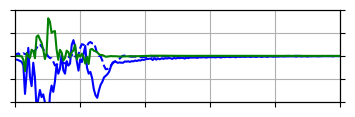

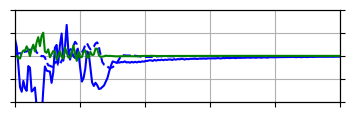

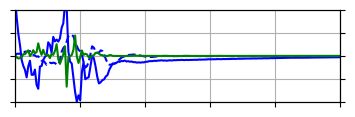

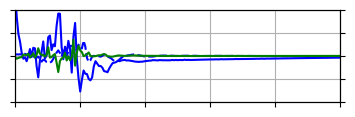

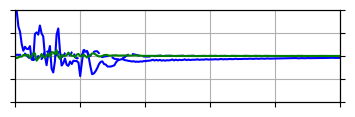

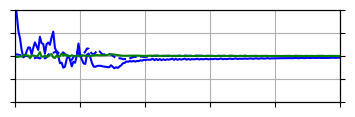

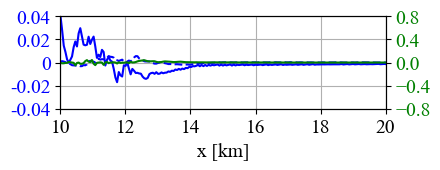

In [45]:
count = 0
for idx_t_data in np.arange(42,100+1,3):
    
    idx_t_ = count+14
    fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(4.2,1.2))

    ax1.plot(data.x.data, U[idx_t_data,:,int(Ny/2)], 'b-', label=r'U [10$\times$ms$^{-1}$]')
    # ax1.plot(data.x.data, W[idx_t_data,:,int(Ny/2)]*1e2, 'b--', label=r'W [10$^3\times$ms$^{-1}$]')
    ax1.plot(data.x.data, W_filter[idx_t_data,:], 'b--', label=r'W [10$^3\times$ms$^{-1}$]')
    
    ax0 = ax1.twinx() 
    ax0.plot(data.x.data, (data_Cadv.Ah0[idx_t_,:,int(Ny/2)].data+C[idx_t_data,:,int(Ny/2)].data), c='green', label=r'C [Wm$^{-2}$]')
    ax0.set_ylim([-.8,.8])
    ax0.set_yticks(np.arange(-.8,.8+1e-4,.4))
    # ax1.plot(data.x.data, C1[idx_t_data,:,int(Ny/2)].data, c='green', label=r'C [Wm$^{-2}$]')
    # ax1.plot(data.x.data, p_prime_[idx_t_data,:,int(Ny/2)].data*1e-6, c='green', label=r'C [Wm$^{-2}$]')

    # ax0.plot(data.x.data, (Cadv_int[idx_t_data,:,int(Ny/2)]+data_.C_int[idx_t_data,:,int(Ny/2)].data), c='green', label=r'C [Wm$^{-2}$]')
 
    ax1.set_xticks(np.arange(x_c+10000,x_c+20000+1,2000))
    ax1.set_xlim([x_c+10000,x_c+20000])
    ax1.set_ylim([-.04,.04])
    ax1.set_yticks(np.arange(-.04,.04+1e-4,.02))
    if idx_t_data == 99:
        ax1.set_yticklabels(['-0.04', '-0.02', '0', '0.02', '0.04'])
        ax1.set_xticklabels(['10', '12', '14', '16', '18', '20'])
        ax1.set_xlabel('x [km]', fontsize=14)
    else:
        ax1.set_yticklabels('')
        ax0.set_yticklabels('')
        ax1.set_xticklabels('')

    ax0.tick_params(axis='both', which='major', labelsize=14, labelcolor='green')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.tick_params(axis='both', which='major', labelsize=14)
    ax1.set_ylabel('')
    ax1.grid(True)

    plt.rcParams["font.family"] = "Times New Roman"
    # fig.tight_layout()
    plt.savefig(outfilepath+ f"U_W_C_slice_summer_nof_t{idx_t_data}.png", transparent=True, dpi=300)

    count+=1
